# CS 280: Ideal Flow Machines

You'll be implementing your own ideal flow machines. This project was developed by [Jorge Diaz Chao](https://jdiazchao.com), [Jiaxin Ge](https://gejiaxin.org), [Angjoo Kanazawa](https://people.eecs.berkeley.edu/~kanazawa/) and [Alexei A. Efros](https://people.eecs.berkeley.edu/~efros/).

In [2]:
import torch
import torchvision
import numpy as np
from tqdm import  tqdm
import torch.nn.functional as F
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset

### Introduction

How do diffusion and/or flow models produce novel outputs? Why wouldn't they just reproduce the training dataset? Where's the creativity coming from? Researches are actively working on these questions. Throughout this project we'll be looking at a paper with very interesting insights.

In *An Analytic Theory of Creativity in Convolutional Diffusion Models* ([arXiv:2412.20292](https://arxiv.org/abs/2412.20292)), Mason Kamb and Surya Ganguli develop analytical models that approximate the ideal diffusion score and achieve impressive results.

You'll be implementing such models in the context of flow matching and comparing them to the outputs of your trained UNet on MNIST. **Note that** before proceeding, you should read the paper.

<div class="alert alert-block alert-info">
  <b>Starter Code</b><br>
  This code is provided as a starting point only. Every component can be freely modified, replaced, or deleted as needed.
</div>

In [3]:
N_DATA = 10_000
N_STEPS = 20
BATCH_SIZE = 64
C, H, W = 1, 32, 32
LABEL = None
N_SAMPLES = 1
SEED = 1

In [4]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda


### Loading the Dataset

We'll be working with MNIST, although you could get experimental and try any other dataset. The original paper shows results on CIFAR-10, FashionMNIST and Celeb-A too.

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 512kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.9MB/s]


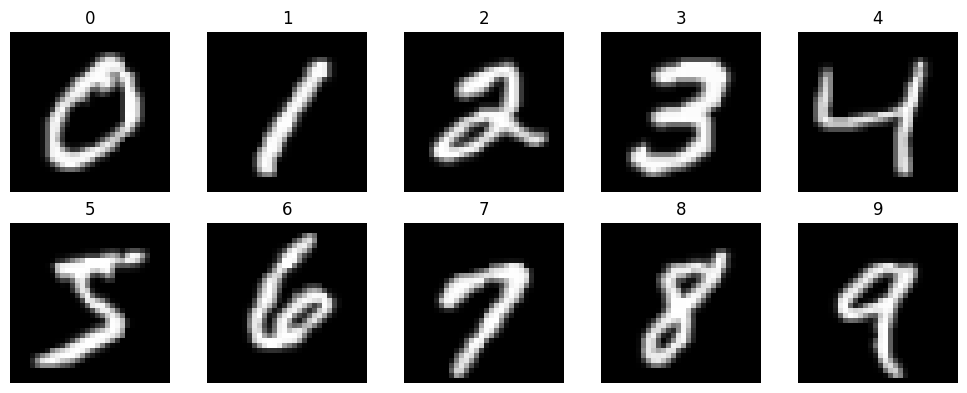

In [5]:
def load_mnist(n_samples):
    transform = transforms.Compose([
        transforms.Resize((H, W)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5]),
    ])
    full = torchvision.datasets.MNIST(
        root='./data', train=True, download=True, transform=transform
    )
    return Subset(full, range(n_samples))

def denormalize(x):
    return x * 0.5 + 0.5

dataset = load_mnist(N_DATA)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

examples = {}
for x, y in dataset:
    if y not in examples:
        examples[y] = x
    if len(examples) == 10:
        break

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for digit, ax in zip(range(10), axes.flatten()):
    x = denormalize(examples[digit]).squeeze(0)
    ax.imshow(x, cmap="gray")
    ax.set_title(f"{digit}")
    ax.axis("off")

plt.tight_layout()
plt.show()

### Your UNet as Reference

Paste your UNet implementation here (or import it) and load a saved checkpoint. Ensure your sampling code can start from a provided noise initialization $x_1$ so generations are reproducible and comparable for different methods.

In [6]:
class AttnBlock(nn.Module):
    def __init__(self, channels: int, num_heads: int = 4):
        super().__init__()

        self.norm = nn.GroupNorm(32, channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            batch_first=True
        )

    def forward(self, x: torch.Tensor):

        B, C, H, W = x.shape

        h = self.norm(x)

        h = h.view(B, C, H*W).permute(0, 2, 1)  # B HW C

        h, _ = self.attn(h, h, h)

        h = h.permute(0, 2, 1).view(B, C, H, W)

        return x + h


class ResBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, t_dim: int):
        super().__init__()

        self.norm1 = nn.GroupNorm(32, in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.norm2 = nn.GroupNorm(32, out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.time_proj = nn.Linear(t_dim, out_channels)

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x: torch.Tensor, t: torch.Tensor):

        h = self.norm1(x)
        h = F.silu(h)
        h = self.conv1(h)

        # add time embedding
        t_emb = self.time_proj(t).unsqueeze(-1).unsqueeze(-1)
        h = h + t_emb

        h = self.norm2(h)
        h = F.silu(h)
        h = self.conv2(h)

        return h + self.skip(x)


class SinusoidalPositionalEmbeddings(nn.Module):
    def __init__(self, dim: int, theta: float = 10000.0):
        super().__init__()

        self.dim = dim
        self.theta = theta

    def forward(self, x: torch.Tensor):

        device = x.device
        half_dim = self.dim // 2

        k = torch.arange(half_dim, device=device)

        freq = torch.exp(-k * torch.log(torch.tensor(self.theta)) / (half_dim - 1))

        args = x[:, None] * freq[None, :]

        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        return emb

class TimeEmbedding(nn.Module):
    def __init__(self, t_dim: int, hidden_dim: int):
        super().__init__()
        self.pos = SinusoidalPositionalEmbeddings(t_dim)
        self.mlp = nn.Sequential(
            nn.Linear(t_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, t_dim)
        )

    def forward(self, t: torch.Tensor):
        t = self.pos(t)
        return self.mlp(t)


class UNet(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        hidden_dim: int = 32,
        t_dim: int = 64
    ):
        super().__init__()

        self.time_embed = TimeEmbedding(t_dim, hidden_dim)

        self.conv_in = nn.Conv2d(in_channels, hidden_dim, 3, padding=1)

        self.res1 = ResBlock(hidden_dim, hidden_dim, t_dim)
        self.attn1 = AttnBlock(hidden_dim)

        self.down = nn.Conv2d(hidden_dim, hidden_dim*2, 3, stride=2, padding=1)

        self.res2 = ResBlock(hidden_dim*2, hidden_dim*2, t_dim)
        self.attn2 = AttnBlock(hidden_dim*2)

        self.mid = ResBlock(hidden_dim*2, hidden_dim*2, t_dim)

        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2),
            nn.Conv2d(hidden_dim*2, hidden_dim, 3, padding=1)
        )

        self.res3 = ResBlock(hidden_dim*2, hidden_dim, t_dim)

        self.norm_out = nn.GroupNorm(32, hidden_dim)
        self.conv_out = nn.Conv2d(hidden_dim, in_channels, 3, padding=1)

    def forward(self, x: torch.Tensor, t: torch.Tensor):

        t = self.time_embed(t)

        x1 = self.conv_in(x)
        x1 = self.res1(x1, t)
        x1 = self.attn1(x1)

        x2 = self.down(x1)
        x2 = self.res2(x2, t)
        x2 = self.attn2(x2)

        mid = self.mid(x2, t)

        x = self.up(mid)

        x = torch.cat([x, x1], dim=1)

        x = self.res3(x, t)

        x = self.norm_out(x)
        x = F.silu(x)

        return self.conv_out(x)


class FlowMatching(nn.Module):
    def __init__(self, model: nn.Module):
        super().__init__()
        self.model = model

    def loss(self, x_0: torch.Tensor):

        B = x_0.shape[0]

        x_1 = torch.randn_like(x_0)

        t = torch.rand(B, device=x_0.device)

        t_view = t.view(B,1,1,1)

        x_t = (1 - t_view) * x_0 + t_view * x_1

        v = x_1 - x_0

        v_pred = self.model(x_t, t)

        loss = F.mse_loss(v_pred, v)

        return loss

    @torch.no_grad()
    def sample(self, size=None, x_1=None, num_inference_steps=50, device=None):

        if x_1 is None:
            x = torch.randn(size).to(device)
        else:
            x = x_1.to(device)

        B = x.shape[0]

        for i in tqdm(range(num_inference_steps)):

            t = torch.ones(B, device=device) * (1 - i/num_inference_steps)

            v = self.model(x, t)

            x = x - v / num_inference_steps

        return x

In [8]:
# initialize model

unet = UNet(
    in_channels=1,
    hidden_dim=32,
    t_dim=64
)

model = FlowMatching(unet).to(device)

ckpt = torch.load("unet_flow_matching.pt", map_location=device)

model.model.load_state_dict(ckpt)

model.eval()

FlowMatching(
  (model): UNet(
    (time_embed): TimeEmbedding(
      (pos): SinusoidalPositionalEmbeddings()
      (mlp): Sequential(
        (0): Linear(in_features=64, out_features=32, bias=True)
        (1): SiLU()
        (2): Linear(in_features=32, out_features=64, bias=True)
      )
    )
    (conv_in): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (res1): ResBlock(
      (norm1): GroupNorm(32, 32, eps=1e-05, affine=True)
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm2): GroupNorm(32, 32, eps=1e-05, affine=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (time_proj): Linear(in_features=64, out_features=32, bias=True)
      (skip): Identity()
    )
    (attn1): AttnBlock(
      (norm): GroupNorm(32, 32, eps=1e-05, affine=True)
      (attn): MultiheadAttention(
        (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
      )
    )


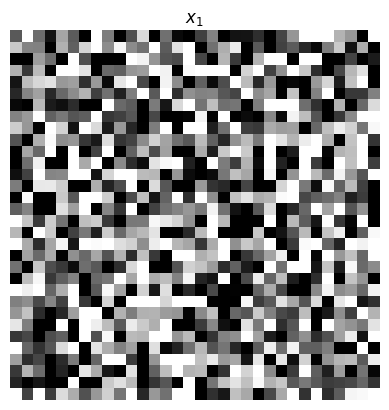

In [9]:
torch.manual_seed(SEED)
x_1 = torch.randn(1, C, H, W, device=device)
# x_1 = torch.load("x_1.pt")

x_1_img = denormalize(x_1[0]).cpu().squeeze().clamp(0, 1)
plt.imshow(x_1_img, cmap='gray')
plt.axis('off')
plt.title("$x_1$")
plt.show()

UNet


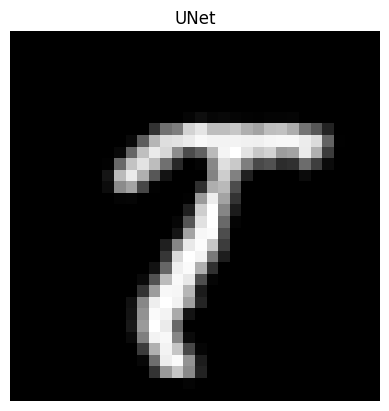

In [10]:
print("UNet")

@torch.no_grad()
def sample_unet(model, x_1, num_steps=20):
    x = x_1.clone()
    dt = -1.0 / (num_steps - 1)

    for i in range(num_steps - 1, 0, -1):
        t = torch.full((x.shape[0],), i / num_steps, device=x.device)

        v = model.model(x, t)

        x = x + dt * v

    return x

x_unet = sample_unet(model, x_1, num_steps=N_STEPS)

x_unet_img = denormalize(x_unet[0]).cpu().squeeze().clamp(0, 1)

plt.imshow(x_unet_img, cmap='gray')
plt.axis('off')
plt.title("UNet")
plt.show()

In the exercises below, you will implement **non-trainable analytic models** that approximate the ideal score/flow. You will use them to mimic your trained UNet’s sampling dynamics and compare the images they produce to your UNet’s outputs.

### Euler Sampler

We sample an image by numerically integrating the flow-matching ODE backward from noise just like we did for our trained model. At each step, the vector field is provided by an analytical model such (e.g. ELS / bbELS) that could depend on a per-step patch scale (or effective receptive field) $k$.

Let $N = \texttt{len(scales)}$. Initialize
$$
x_1 \sim \mathcal N(0, I) \quad\text{(or } x_1 = \texttt{x\_1}\text{)}.
$$
For steps $i = N-1, \dots, 1$, define
$$
t_i = \frac{i}{N}, \qquad k_i = \texttt{scales}[i],
$$
evaluate the vector field
$$
v_i = \texttt{model}(t_i, x_i, \texttt{dataloader},\, k=k_i, \ldots),
$$
and take a backward Euler step
$$
x_{i-1} = x_i + \Delta t\, v_i,
\qquad
\Delta t = -\frac{1}{N-1}.
$$

Return $x_0$ as the generated sample.

**Note that** your euler sampler should allow you to display intermediate denoising steps.

In [11]:
SCALES = [3, 3, 3, 5, 5, 7, 7, 7, 9, 9, 9, 11, 13, 15, 17, 21, 23, 23, 25, 27]

In [12]:
@torch.no_grad()
def flow_euler_solver(
    model,
    dataloader,
    scales,
    x_1
):
    """
    Euler integration for optimal transport flow matching.
    """

    num_inference_steps = len(scales)

    x = x_1.clone()

    dt = -1.0 / (num_inference_steps - 1)

    for i in range(num_inference_steps - 1, 0, -1):

        t = torch.full((x.shape[0],), i / num_inference_steps, device=x.device)

        k = scales[i]

        v = model(t, x, dataloader, k=k)

        x = x + dt * v

    return x

### Ideal Flow Machines

The paper *An Analytic Theory of Creativity in Convolutional Diffusion Models* ([arXiv:2412.20292](https://arxiv.org/abs/2412.20292)) introduces us to numerous ideal score machines which we'll be implementing in order of appearance in the paper and complexity, but not necessarily accuracy. We refer to our machines as ideal flow machines since we are working with a velocity model instead of a score or noise model like the original paper.

<p align="center">
    <img src="figures/figure_2.png" width="400">
</p>

You should look at the paper and understand the method, however, here's a brief overview. For every pixel, we define a score over training patches based on how well their
$k \times k$ neighborhoods match the neighborhood of $x$, defined as
$$
\ell(p) \;=\; -\frac{\|x_{\text{patch}} - a_t\,p\|_2^2}{2\,b_t^2},
$$
where the squared distance expands as
$$
\|x_{\text{patch}} - a_t p\|^2
= \|x_{\text{patch}}\|^2 - 2a_t\langle x_{\text{patch}},p\rangle + a_t^2\|p\|^2.
$$

Each patch proposes a local correction based on its center pixel,
$$
v(p) \;=\; x - a_t\,p_{\text{center}}.
$$

These proposals are aggregated using a softmax-weighted expectation,
$$
E_{\text{diff}} \;=\; \frac{\sum_p e^{\ell(p)}\,v(p)}{\sum_p e^{\ell(p)}}.
$$

The returned vector field is obtained from this expected correction as
$$
\text{velocity} \;=\; \frac{E_{\text{diff}}}{b_t}\;-\;\frac{x - E_{\text{diff}}}{a_t}.
$$
With linear flow matching, $x_t = (1 - t)\,x_0 + t\,x_1$, so $a_t = 1 - t$ and $b_t = t$.

The difference between IS, LS, ELS, and bbELS machines are based on whether we use patches or not (each image is a one patch), and which pair of patches we compare to.

<p align="center">
    <img src="figures/results.png" width="1200">
</p>

### Log-sum-exp accumulation (streaming softmax)

For constructions below, we must compute quantities of the form
$$
\frac{\sum_j e^{w_j}\, v_j}{\sum_j e^{w_j}},
$$
where $w_j$ are log-weights and $v_j$ are associated values.

When the index set $j$ is very large (such as for all patches in a dataset), it may be
impractical or impossible to materialize all $w_j$ and $v_j$ at once.

The provided helper function implements a **numerically stable, streaming
log-sum-exp accumulation** of this weighted average across minibatches.
It maintains running accumulators for the numerator and denominator while
rescaling them as needed using a per-location maximum, ensuring stability even
when the log-weights have large magnitude.

Concretely, given minibatches $\{w_m, v_m\}$, it updates running estimates
proportional to
$$
\text{num} \leftarrow \sum_m e^{w_m} v_m,
\qquad
\text{den} \leftarrow \sum_m e^{w_m},
$$
without ever forming the full softmax explicitly.

You may find this useful whenever a softmax-weighted expectation must be computed
over a large or streaming set of terms.

In [13]:
def lse_accumulate(numerator, denominator, subtraction, exp_args, values):
    """
    Update running accumulators for a softmax-weighted average across minibatches using
    numerically stable log-sum-exp accumulation.

    Args:
        numerator: Running weighted sum, shape [B, C, H, W].
        denominator: Running weight sum, shape [B, H, W].
        subtraction: Stabilization state (or None to initialize).
        exp_args: Log-weights for the current minibatch, shape [B, M, H, W].
        values: Values to be averaged, shape [B, M, C, H, W].

    Returns:
        Updated (numerator, denominator, subtraction).
    """
    if subtraction is None:
        subtraction = torch.amax(exp_args, dim=(0, 1), keepdim=True)
    else:
        new_sub = torch.amax(exp_args, dim=(0, 1), keepdim=True)
        delta = torch.maximum(new_sub, subtraction)
        numerator  /= torch.exp(delta - subtraction)
        denominator /= torch.exp(delta - subtraction)[:, 0, :, :]
        subtraction = delta

    exp_vals = torch.exp(exp_args - subtraction)
    numerator  += torch.mean(exp_vals[:, :, None, :, :] * values, dim=1)
    denominator += torch.mean(exp_vals, dim=1)

    return numerator, denominator, subtraction

Alternatively, if constrained by computational budget or would like to avoid accumulation, compute the same softmax-weighted average over only the K nearest neighbors which would result in an approximation.

<div class="alert alert-block alert-info">
<b>IS</b><br>
The Ideal Score (IS) machine only reproduces the training set. Every denoising step, it moves closer to a weighted average of the training images. It would mimic the behavior of the diffusion and/or flow model if it only were able to memorize the data distribution, which we know to be not true.
</div>

In [14]:
@torch.no_grad()
def is_vector_field(t, x, dataloader, k):
    b, c, h, w = x.shape
    device = x.device

    # a_t, b_t
    at = (1 - t).to(device).view(b, 1, 1, 1)
    bt = t.to(device).view(b, 1, 1, 1)

    numerator = torch.zeros(b, c, h, w, device=device)
    denominator = torch.zeros(b, h, w, device=device)
    subtraction = None

    for images, labels in dataloader:
        images = images.to(device)                 # [M, C, H, W]
        M = images.shape[0]

        # expand training images to batch dimension
        p = images.unsqueeze(0).expand(b, M, c, h, w)

        # log-weight ℓ(p) = -||x - a_t p||^2 / (2 b_t^2)
        diff = x[:, None] - at[:, None] * p        # [B, M, C, H, W]
        dist2 = (diff ** 2).sum(dim=(2,3,4))       # [B, M]

        logw = -dist2 / (2 * (bt[:,0,0,0]**2)[:,None] + 1e-8)

        # broadcast to [B, M, H, W] for the accumulator
        exp_args = logw[:, :, None, None].expand(b, M, h, w)

        # v(p) = x - a_t p
        values = diff                              # [B, M, C, H, W]

        numerator, denominator, subtraction = lse_accumulate(
            numerator,
            denominator,
            subtraction,
            exp_args,
            values
        )

    # E_diff
    E_diff = numerator / (denominator[:, None] + 1e-8)

    # velocity
    vel = E_diff / bt - (x - E_diff) / at

    return vel

IS


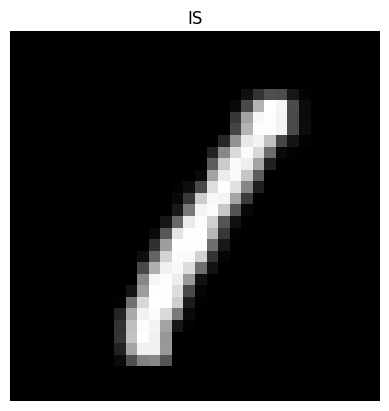

In [15]:
print("IS")

x_is = flow_euler_solver(
    model=is_vector_field,
    dataloader=dataloader,
    scales=SCALES,
    x_1=x_1
)

x_is_img = denormalize(x_is[0]).cpu().squeeze().clamp(0, 1)
plt.imshow(x_is_img, cmap='gray')
plt.axis('off')
plt.title("IS")
plt.show()

<div class="alert alert-block alert-info">
<b>LS</b><br>
The Local Score (LS) machine reflects the locality bias of convolutions in the UNet. At each pixel, it compares co-located patches from the training set and moves the pixel toward a weighted average of their center values.
</div>

At each pixel location, the model compares its neighborhood patch to training patches from the same location. Implement a function to extract these co-located patches from a batch of images and use it when building the LS machine.

It could be useful for the future if the function returned the squared norm of each patch and its center pixel value, to determine the similarity score and contribution of the center pixel.

In [16]:
@torch.no_grad()
def extract_patches_grid(images, k, pad_mode="circular", pad_value=0.0):
    """
    Extract co-located k x k patches for every spatial location.

    Returns:
        patches: [B, H, W, C*k*k]
        norms:   [B, H, W]
        centers: [B, C, H, W]
    """
    b, c, h, w = images.shape
    pad = k // 2

    if pad_mode == "circular":
        x = F.pad(images, (pad, pad, pad, pad), mode="circular")
    else:
        x = F.pad(images, (pad, pad, pad, pad), mode="constant", value=pad_value)

    patches = F.unfold(x, kernel_size=k)                    # [B, C*k*k, H*W]
    patches = patches.transpose(1, 2).reshape(b, h, w, c * k * k)

    norms = (patches ** 2).sum(dim=-1)

    center_idx = (k * k) // 2
    centers = torch.stack(
        [patches[..., ch * k * k + center_idx] for ch in range(c)],
        dim=-1
    )                                                       # [B,H,W,C]
    centers = centers.permute(0, 3, 1, 2).contiguous()     # [B,C,H,W]

    return patches, norms, centers

In [17]:
@torch.no_grad()
def ls_vector_field(t, x, dataloader, k):
    b, c, h, w = x.shape
    device = x.device

    at = (1 - t).to(device).view(b, 1, 1)
    bt = t.to(device).view(b, 1, 1)

    x_patches, x_norms, _ = extract_patches_grid(x, k, pad_mode="circular")

    numerator = torch.zeros(b, c, h, w, device=device)
    denominator = torch.zeros(b, h, w, device=device)
    subtraction = None

    for images, labels in dataloader:
        images = images.to(device)

        p_patches, p_norms, p_centers = extract_patches_grid(
            images, k, pad_mode="circular"
        )

        dots = torch.einsum("bhwd,mhwd->bmhw", x_patches, p_patches)

        dist2 = (
            x_norms[:, None, :, :]
            - 2 * at[:, None, :, :] * dots
            + (at[:, None, :, :] ** 2) * p_norms[None, :, :, :]
        )

        exp_args = -dist2 / (2 * (bt[:, None, :, :] ** 2) + 1e-8)

        values = x[:, None, :, :, :] - at[:, None, None, :, :] * p_centers[None, :, :, :, :]

        numerator, denominator, subtraction = lse_accumulate(
            numerator, denominator, subtraction, exp_args, values
        )

    E_diff = numerator / (denominator[:, None] + 1e-8)
    vel = E_diff / bt[:, None, :, :] - (x - E_diff) / at[:, None, :, :]
    return vel

LS


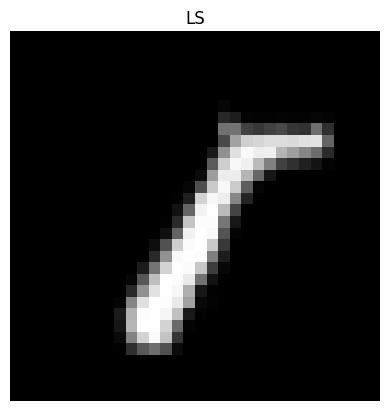

In [18]:
print("LS")

x_ls = flow_euler_solver(
    model=ls_vector_field,
    dataloader=dataloader,
    scales=SCALES,
    x_1=x_1
)

x_ls_img = denormalize(x_ls[0]).cpu().squeeze().clamp(0, 1)
plt.imshow(x_ls_img, cmap='gray')
plt.axis('off')
plt.title("LS")
plt.show()

Note that for MNIST in particular, since digits are centered LS might work particularly well, although this isn't true in general.

<div class="alert alert-block alert-info">
<b>ELS</b><br>
The Equivariant Local Score (ELS) machine further recognizes the equivariant inductive bias from convolutions and attempts to model it with any other patch not neceesarly centered at the same pixel location.
</div>

Since the ELS machine now compares the patch to every other in the training dataset independently of where it's centered, you might have to modify your previous implementation of the function resposinble of extracting the patches.

In [19]:
@torch.no_grad()
def extract_patches(images, k):
    """
    Extract all k×k patches from images.

    Returns:
        patches: [M*H*W, C*k*k]
        norms:   [M*H*W]
        centers: [M*H*W, C]
    """
    m, c, h, w = images.shape
    pad = k // 2

    x = F.pad(images, (pad, pad, pad, pad), mode="circular")
    patches = F.unfold(x, kernel_size=k)                  # [M, C*k*k, H*W]
    patches = patches.permute(0, 2, 1).reshape(-1, c * k * k)

    norms = (patches ** 2).sum(dim=-1)

    center_idx = (k * k) // 2
    centers = torch.stack(
        [patches[:, ch * k * k + center_idx] for ch in range(c)],
        dim=-1
    )                                                     # [M*H*W, C]

    return patches, norms, centers

In [20]:
@torch.no_grad()
def els_vector_field(t, x, dataloader, k, patch_chunk=1024):
    b, c, h, w = x.shape
    device = x.device

    at = (1 - t).to(device).view(b, 1, 1)
    bt = t.to(device).view(b, 1, 1)

    x_patches, x_norms, _ = extract_patches_grid(x, k, pad_mode="circular")

    numerator = torch.zeros(b, c, h, w, device=device)
    denominator = torch.zeros(b, h, w, device=device)
    subtraction = None

    for images, labels in dataloader:
        images = images.to(device)

        p_patches, p_norms, p_centers = extract_patches(images, k)
        n_total = p_patches.shape[0]

        for start in range(0, n_total, patch_chunk):
            end = min(start + patch_chunk, n_total)

            p_patch_chunk = p_patches[start:end]      # [N,D]
            p_norm_chunk = p_norms[start:end]         # [N]
            p_center_chunk = p_centers[start:end]     # [N,C]

            dots = torch.einsum("bhwd,nd->bnhw", x_patches, p_patch_chunk)

            dist2 = (
                x_norms[:, None, :, :]
                - 2 * at[:, None, :, :] * dots
                + (at[:, None, :, :] ** 2) * p_norm_chunk[None, :, None, None]
            )

            exp_args = -dist2 / (2 * (bt[:, None, :, :] ** 2) + 1e-8)

            values = (
                x[:, None, :, :, :]
                - at[:, None, None, :, :] * p_center_chunk[None, :, :, None, None]
            )

            numerator, denominator, subtraction = lse_accumulate(
                numerator,
                denominator,
                subtraction,
                exp_args,
                values
            )

    E_diff = numerator / (denominator[:, None] + 1e-8)
    vel = E_diff / bt[:, None, :, :] - (x - E_diff) / at[:, None, :, :]
    return vel

ELS


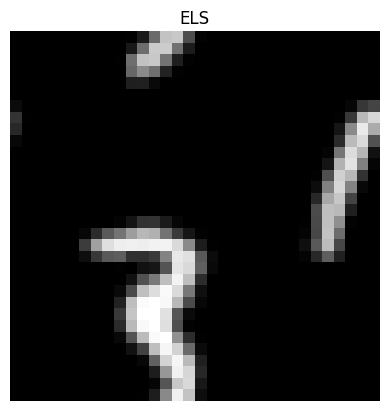

In [21]:
print("ELS")

x_els = flow_euler_solver(
    model=els_vector_field,
    dataloader=dataloader,
    scales=SCALES,
    x_1=x_1
)

x_els_img = denormalize(x_els[0]).cpu().squeeze().clamp(0, 1)
plt.imshow(x_els_img, cmap='gray')
plt.axis('off')
plt.title("ELS")
plt.show()

<div class="alert alert-block alert-info">
<b>bbELS</b><br>
The Boundary-Broken Equivariant Local Score (bbELS) machine accounts for the fact that patches near image borders contain location information. Border patches are compared only with training patches at similar relative positions to the boundary, while interior patches remain fully equivariant and are compared with all patches of the same shape.
</div>

To reflect this, patch extraction and matching near the boundaries must respect boundary structure. We enforce this by utilizing fixed padding instead of circular padding, so border patches are only matched to training patches with the same boundary overlap pattern.

You will now modify the patch extraction and vector field to implement the boundary-broken variant. The boundary constraint can be enforced or approximated in different ways, you are free to choose a reasonable implementation.

In [22]:
@torch.no_grad()
def extract_patches_padded(images, k, pad_value=0.0):
    """
    Extract all k×k patches with zero padding (boundary aware).

    Returns
    -------
    patches  : [M*H*W, C*k*k]
    norms    : [M*H*W]
    centers  : [M*H*W, C]
    """

    m, c, h, w = images.shape
    pad = k // 2

    x = F.pad(images, (pad, pad, pad, pad), mode="constant", value=pad_value)

    patches = F.unfold(x, kernel_size=k)          # [M, C*k*k, H*W]
    patches = patches.permute(0,2,1).reshape(-1, c*k*k)

    norms = (patches ** 2).sum(dim=-1)

    center_idx = (k * k) // 2
    centers = torch.stack(
        [patches[:, ch * k * k + center_idx] for ch in range(c)],
        dim=-1
    )

    return patches, norms, centers

In [23]:
@torch.no_grad()
def extract_patches_padded(images, k, pad_value=0.0):
    """
    Extract all k×k patches with zero padding (boundary aware).

    Returns
    -------
    patches  : [M*H*W, C*k*k]
    norms    : [M*H*W]
    centers  : [M*H*W, C]
    """

    m, c, h, w = images.shape
    pad = k // 2

    x = F.pad(images, (pad, pad, pad, pad), mode="constant", value=pad_value)

    patches = F.unfold(x, kernel_size=k)          # [M, C*k*k, H*W]
    patches = patches.permute(0,2,1).reshape(-1, c*k*k)

    norms = (patches ** 2).sum(dim=-1)

    center_idx = (k*k)//2
    centers = patches[:, center_idx*c:(center_idx+1)*c]

    return patches, norms, centers

In [24]:
@torch.no_grad()
def bbels_vector_field(t, x, dataloader, k):

    b, c, h, w = x.shape
    device = x.device

    at = (1 - t).to(device).view(b,1,1)
    bt = t.to(device).view(b,1,1)

    # query patches (zero padding)
    x_patches, x_norms, _ = extract_patches_grid(
        x, k, pad_mode="constant"
    )

    numerator = torch.zeros(b, c, h, w, device=device)
    denominator = torch.zeros(b, h, w, device=device)
    subtraction = None

    for images, labels in dataloader:

        images = images.to(device)

        p_patches, p_norms, p_centers = extract_patches_padded(images, k)

        p_patches = p_patches.view(-1, c*k*k)
        p_norms = p_norms.view(-1)
        p_centers = p_centers.view(-1, c)

        dots = torch.einsum(
            "bhwd,nd->bnhw",
            x_patches,
            p_patches
        )

        dist2 = (
            x_norms[:,None,:,:]
            - 2*at[:,None,:,:]*dots
            + (at[:,None,:,:]**2)*p_norms[None,:,None,None]
        )

        exp_args = -dist2 / (2*(bt[:,None,:,:]**2)+1e-8)

        values = (
            x[:,None,:,:,:]
            - at[:,None,None,:,:]*p_centers[None,:, :,None,None]
        )

        numerator, denominator, subtraction = lse_accumulate(
            numerator,
            denominator,
            subtraction,
            exp_args,
            values
        )

    E_diff = numerator/(denominator[:,None]+1e-8)

    vel = E_diff/bt[:,None,:,:] - (x-E_diff)/at[:,None,:,:]

    return vel

In [25]:
@torch.no_grad()
def bbels_vector_field(t, x, dataloader, k):

    b, c, h, w = x.shape
    device = x.device

    at = (1 - t).to(device).view(b,1,1)
    bt = t.to(device).view(b,1,1)

    # query patches (zero padding)
    x_patches, x_norms, _ = extract_patches_grid(
        x, k, pad_mode="constant"
    )

    numerator = torch.zeros(b, c, h, w, device=device)
    denominator = torch.zeros(b, h, w, device=device)
    subtraction = None

    for images, labels in dataloader:

        images = images.to(device)

        p_patches, p_norms, p_centers = extract_patches_padded(images, k)

        p_patches = p_patches.view(-1, c*k*k)
        p_norms = p_norms.view(-1)
        p_centers = p_centers.view(-1, c)

        dots = torch.einsum(
            "bhwd,nd->bnhw",
            x_patches,
            p_patches
        )

        dist2 = (
            x_norms[:,None,:,:]
            - 2*at[:,None,:,:]*dots
            + (at[:,None,:,:]**2)*p_norms[None,:,None,None]
        )

        exp_args = -dist2 / (2*(bt[:,None,:,:]**2)+1e-8)

        values = (
            x[:,None,:,:,:]
            - at[:,None,None,:,:]*p_centers[None,:, :,None,None]
        )

        numerator, denominator, subtraction = lse_accumulate(
            numerator,
            denominator,
            subtraction,
            exp_args,
            values
        )

    E_diff = numerator/(denominator[:,None]+1e-8)

    vel = E_diff/bt[:,None,:,:] - (x-E_diff)/at[:,None,:,:]

    return vel

bbELS


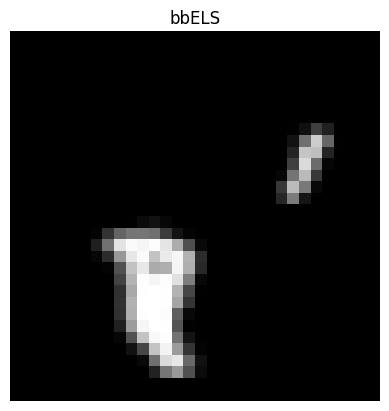

In [26]:
print("bbELS")

x_bbels = flow_euler_solver(
    model=bbels_vector_field,
    dataloader=dataloader,
    scales=SCALES,
    x_1=x_1
)

x_bbels_img = denormalize(x_bbels[0]).cpu().squeeze().clamp(0, 1)
plt.imshow(x_bbels_img, cmap='gray')
plt.axis('off')
plt.title("bbELS")
plt.show()

## Deliverables

This code generates multiple noisy starting points by adding small perturbations to a fixed base noise (x_1), ensuring consistent and comparable initializations. For each noise sample, it runs five different models (UNet, IS, LS, ELS, and bbELS) to produce outputs from the same starting point. The results are stored and visualized side by side, allowing direct comparison of how each method transforms the same noise into an image. Finally, a subset of representative samples is selected for clearer presentation.


In [33]:
NUM_SAMPLES = 8

base = torch.load("x_1.pt", map_location="cpu").to(device)

torch.manual_seed(42)

x1_list = [
    base + 0.05 * torch.randn_like(base)
    for _ in range(NUM_SAMPLES)
]

In [34]:
results = []

for i, x1 in enumerate(x1_list):
    print(f"Sample {i}")

    x_unet = sample_unet(model, x1, num_steps=N_STEPS)
    x_is   = flow_euler_solver(is_vector_field, dataloader, SCALES, x1)
    x_ls   = flow_euler_solver(ls_vector_field, dataloader, SCALES, x1)
    x_els  = flow_euler_solver(els_vector_field, dataloader, SCALES, x1)
    x_bb   = flow_euler_solver(bbels_vector_field, dataloader, SCALES, x1)

    results.append((x1, x_unet, x_is, x_ls, x_els, x_bb))

Sample 0
Sample 1
Sample 2
Sample 3
Sample 4
Sample 5
Sample 6
Sample 7


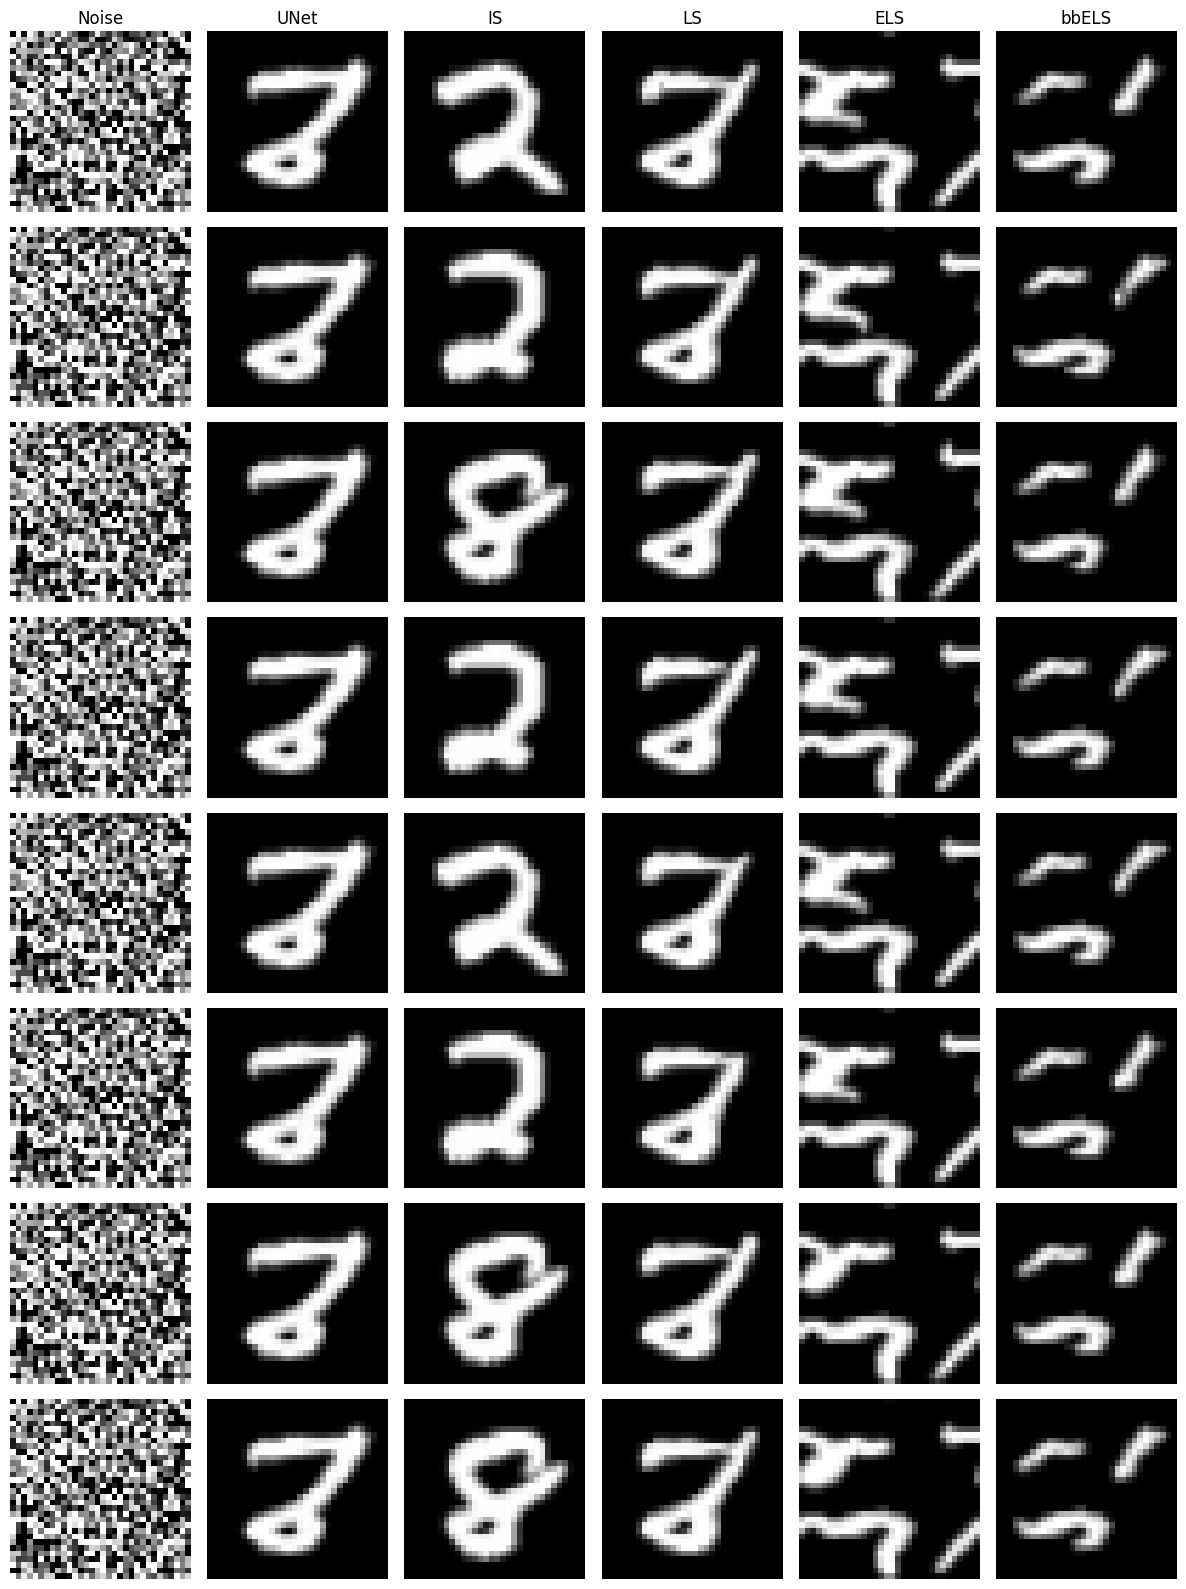

In [35]:
def show_comparison(results):
    n = len(results)

    fig, axes = plt.subplots(n, 6, figsize=(12, 2*n))

    titles = ["Noise", "UNet", "IS", "LS", "ELS", "bbELS"]

    for j in range(6):
        axes[0, j].set_title(titles[j])

    for i, (x1, xu, xi, xl, xe, xb) in enumerate(results):
        imgs = [x1, xu, xi, xl, xe, xb]

        for j in range(6):
            img = denormalize(imgs[j][0]).cpu().squeeze().clamp(0,1)
            axes[i, j].imshow(img, cmap="gray")
            axes[i, j].axis("off")

    plt.tight_layout()
    plt.show()

show_comparison(results)

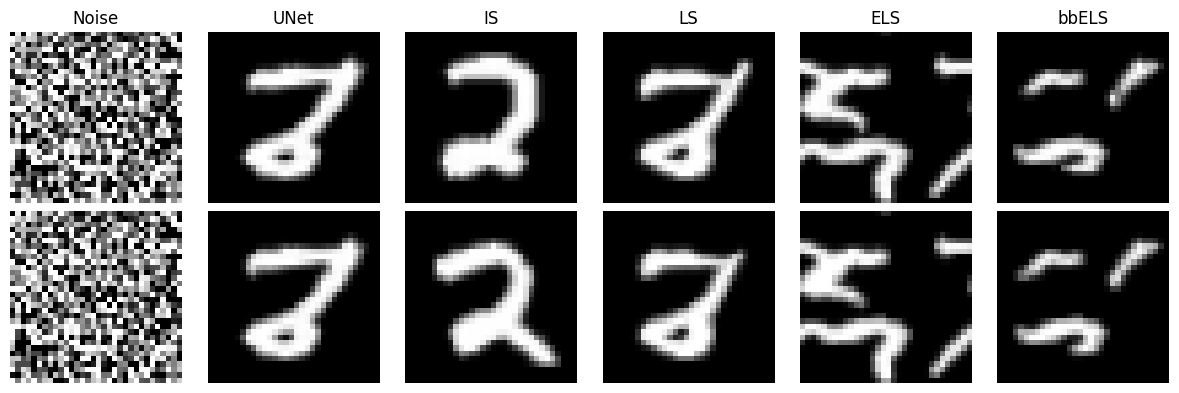

In [48]:
selected = results[1], results[4]
show_comparison(selected)